In [1]:
import pandas as pd
import sqlite3

In [2]:
orders = pd.read_csv("/home/hanysaa/store_orders.csv")
customers = pd.read_csv("/home/hanysaa/store_customers.csv")

In [3]:
orders.head()

,order_id,customer_id,product,category,amount,order_date
0,5000,4,paper,office,14.09,2026-05-25
1,5001,15,planner,office,51.86,2026-05-08
2,5002,34,shelf,furniture,116.25,2026-06-03
3,5003,2,granola,snacks,19.72,2026-05-19
4,5004,17,monitor,electronics,284.80,2026-05-10


In [4]:
customers.head()

,customer_id,name,city,signup_year
0,1,Ana Lopez,Venice,2021
1,2,Ben Kim,Culver City,2023
2,3,Chloe Nguyen,Santa Monica,2021
3,4,Dev Patel,Los Angeles,2026
4,5,Elena Garcia,Culver City,2022


In [5]:
orders.head()

,order_id,customer_id,product,category,amount,order_date
0,5000,4,paper,office,14.09,2026-05-25
1,5001,15,planner,office,51.86,2026-05-08
2,5002,34,shelf,furniture,116.25,2026-06-03
3,5003,2,granola,snacks,19.72,2026-05-19
4,5004,17,monitor,electronics,284.80,2026-05-10


In [6]:
con = sqlite3.connect("store.db")

In [7]:
orders.to_sql("orders", con, index=False, if_exists="replace")

200

In [8]:
customers.to_sql("customers", con, index=False, if_exists="replace")

40

In [9]:
pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", con)


,name
0,orders
1,customers


In [10]:
pd.read_sql("SELECT * FROM orders LIMIT 5", con)

,order_id,customer_id,product,category,amount,order_date
0,5000,4,paper,office,14.09,2026-05-25
1,5001,15,planner,office,51.86,2026-05-08
2,5002,34,shelf,furniture,116.25,2026-06-03
3,5003,2,granola,snacks,19.72,2026-05-19
4,5004,17,monitor,electronics,284.80,2026-05-10


In [11]:
pd.read_sql("""
SELECT *
FROM orders
WHERE amount > 100
ORDER BY amount DESC
""", con)

,order_id,customer_id,product,category,amount,order_date
0,5153,20,dock,electronics,499.00,2026-05-25
1,5140,30,headset,electronics,295.36,2026-05-26
2,5047,901,headset,electronics,293.79,2026-05-15
3,5150,903,monitor,electronics,293.35,2026-06-06
4,5014,6,monitor,electronics,287.83,2026-05-22
...,...,...,...,...,...,...
79,5107,38,shelf,furniture,110.31,2026-05-17
80,5046,13,shelf,furniture,108.47,2026-05-28
81,5009,14,chair,furniture,107.20,2026-05-24
82,5007,36,dock,electronics,103.77,2026-05-21


In [12]:
pd.read_sql("""
SELECT category,
       COUNT(*) AS n,
       AVG(amount) AS avg_amount
FROM orders
GROUP BY category
ORDER BY avg_amount DESC
""", con)

,category,n,avg_amount
0,electronics,60,190.569500
1,furniture,46,146.251522
2,office,51,30.132549
3,snacks,43,14.619767


the total orders is correct which is 200 orders,however, electronics earn the highest avergae amount which is 190.56 wirh a total orders equal 60

In [13]:
pd.read_sql("""
SELECT c.city,
       SUM(o.amount) AS total_spend
FROM orders o
JOIN customers c
    ON o.customer_id = c.customer_id
GROUP BY c.city
ORDER BY total_spend DESC
""", con)

,city,total_spend
0,Los Angeles,5862.99
1,Culver City,5316.88
2,Santa Monica,4017.93
3,Inglewood,2718.25
4,Torrance,1037.25
5,Venice,462.36


In [14]:
pd.read_sql("""
SELECT COUNT(*) AS order_count
FROM orders
""", con)

,order_count
0,200


In [15]:
pd.read_sql("""
SELECT COUNT(*) AS joined_count
FROM orders o
JOIN customers c
    ON o.customer_id = c.customer_id
""", con)

,joined_count
0,195


since we use inner join ,we only shwon  a 195 rows which is less 5 rows to the order table ,because the custmoer_Id in the oder table don't match the customer _id on Joined table.


In [16]:
city_spend = pd.read_sql("""
SELECT c.city,
       SUM(o.amount) AS total_spend
FROM orders o
JOIN customers c
    ON o.customer_id = c.customer_id
GROUP BY c.city
ORDER BY total_spend DESC
""", con)

city_spend

,city,total_spend
0,Los Angeles,5862.99
1,Culver City,5316.88
2,Santa Monica,4017.93
3,Inglewood,2718.25
4,Torrance,1037.25
5,Venice,462.36


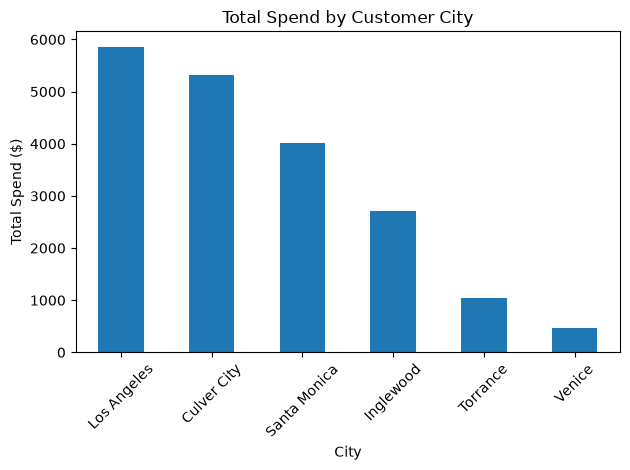

In [17]:
import matplotlib.pyplot as plt

city_spend.plot(
    kind="bar",
    x="city",
    y="total_spend",
    legend=False
)

plt.title("Total Spend by Customer City")
plt.xlabel("City")
plt.ylabel("Total Spend ($)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [18]:
pd.read_sql("""
SELECT product,
       AVG(amount) AS avg_amount
FROM orders
GROUP BY product
ORDER BY avg_amount DESC
""", con)

,product,avg_amount
0,headset,213.143478
1,monitor,186.748824
2,dock,167.857000
3,shelf,159.497368
4,chair,152.348824
5,desk,110.719000
6,planner,31.725385
7,pens,29.889000
8,paper,29.252778
9,tea,15.500714


Which product has the highest average order amount?

headset the highest average order amount which is 213.14 per oderes.

Ethics note
by providing my nootbook publicly,I will be sure to note shae the shore customer_id Data base,which contains the full name of the customers and there full address or anyother personal information.I will only share the publick information about spending moeny for which cataegory or which city has the most orders.